# Fase 1.3 — Análisis Exploratorio de Datos (EDA) y modelo baseline
## Mantenimiento predictivo industrial — AI4I 2020

**Curso:** Aprendizaje Automático en la Nube — Especialización en Ciencia de Datos e Inteligencia Artificial, Universidad de Medellín
**Grupo:** Esteban Marín, Diana Tuberquía, Carolina Tobón

**Objetivo de este notebook:** explorar el dataset AI4I 2020 Predictive Maintenance
para entender su estructura, calidad y las relaciones entre variables, y entrenar un
primer modelo baseline de clasificación de `Machine failure`. Ver
`docs/01_problema_negocio.md` para el detalle del problema de negocio, las métricas
de éxito y el alcance del proyecto.

**Contenido:**
1. Carga del dataset
2. Verificación de integridad (nulos y duplicados)
3. Distribución de la variable objetivo
4. Distribución de variables numéricas
5. Variables numéricas vs. Machine failure
6. Variable categórica Type
7. Correlación entre variables
8. Modelo baseline

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, HistGradientBoostingClassifier, AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    recall_score, precision_score, f1_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_sample_weight

In [22]:

df = pd.read_csv("../data/raw/ai4i2020.csv", encoding="utf-8-sig")
print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 2. Verificación de integridad

Antes de analizar cualquier variable, hay que confirmar que los datos están "limpios":
que no falten valores (nulos) y que no haya filas repetidas. Si hubiera nulos o
duplicados, tocaría decidir cómo tratarlos (imputar, eliminar, etc.) antes de seguir
con el resto del EDA.

In [23]:
print("Nulos por columna:")
print(df.isnull().sum())
print()
print("Filas duplicadas:", df.duplicated().sum())

Nulos por columna:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Filas duplicadas: 0


**Análisis:** el dataset está completamente limpio en este sentido — 0 valores nulos
en las 14 columnas y 0 filas duplicadas. Esto confirma lo esperado de un dataset
sintético como AI4I 2020 (generado programáticamente, sin errores de captura típicos
de datos reales de sensores). No se requiere imputación ni deduplicación antes de
seguir con el análisis.

## 3. Distribución de la variable objetivo (`Machine failure`)

Antes de mirar las variables predictoras, hay que confirmar qué tan desbalanceada
está la variable objetivo. Esto es clave: si las fallas son una minoría muy pequeña,
accuracy deja de ser una métrica confiable (un modelo que siempre prediga "no falla"
tendría accuracy alta sin ser útil) — por eso en la Sección 1.1 se priorizó Recall,
Precision y F1 sobre accuracy.

In [24]:
print(df["Machine failure"].value_counts())
print()
print(df["Machine failure"].value_counts(normalize=True).round(4) * 100)

Machine failure
0    9661
1     339
Name: count, dtype: int64

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


**Análisis:** el desbalance es fuerte — apenas el 3.39% de las observaciones (339 de
10.000) corresponden a una falla real. Esto confirma la decisión tomada en la
Sección 1.1: usar Recall, Precision, F1 y AUC-PR como métricas principales, no
accuracy. También implica que, más adelante, en el split train/test hay que
**estratificar por la variable objetivo** (para que la proporción de fallas se
mantenga igual en ambos conjuntos), y que probablemente haya que usar técnicas de
balanceo de clases (como SMOTE, que ya dejamos instalado con imbalanced-learn) en
la Fase 2.

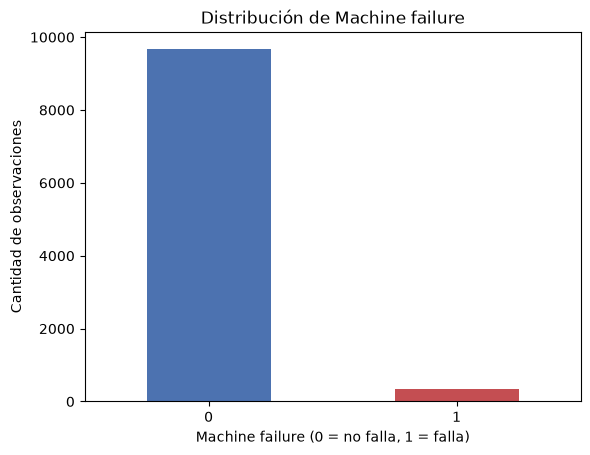

In [25]:


df["Machine failure"].value_counts().plot(kind="bar", color=["#4C72B0", "#C44E52"])
plt.title("Distribución de Machine failure")
plt.xlabel("Machine failure (0 = no falla, 1 = falla)")
plt.ylabel("Cantidad de observaciones")
plt.xticks(rotation=0)
plt.show()

## 4. Distribución de las variables numéricas

Ahora miramos cómo se distribuye cada variable predictora numérica (temperaturas,
velocidad rotacional, torque, desgaste de herramienta) de forma individual, para
detectar su forma (¿normal?, ¿sesgada?), posibles outliers, y el rango de valores
que manejan — información clave antes de decidir si hace falta escalarlas o
transformarlas para el modelo.

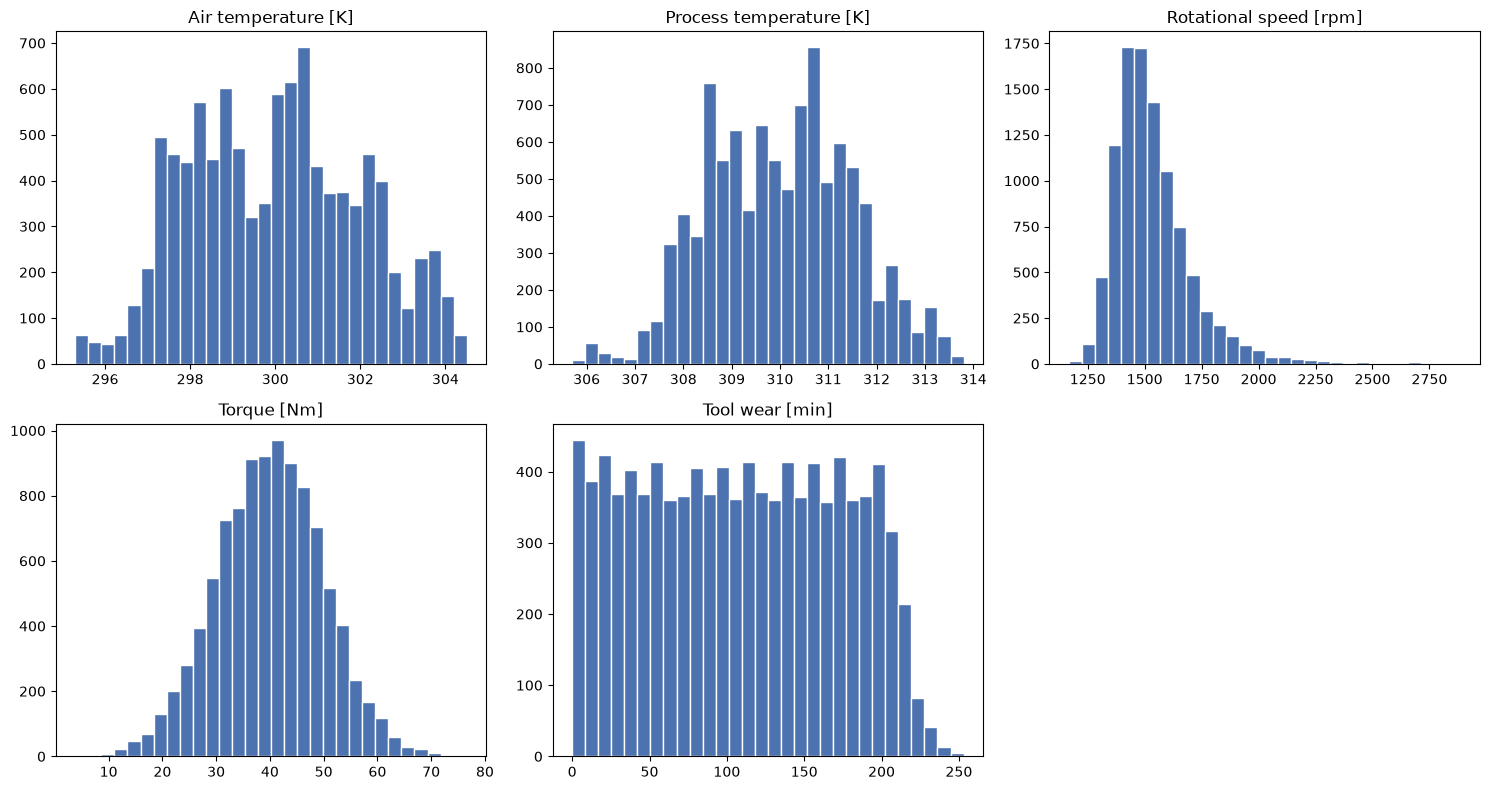

In [26]:
num_cols = [
    "Air temperature [K]", "Process temperature [K]",
    "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color="#4C72B0", edgecolor="white")
    axes[i].set_title(col)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

**Análisis:**
- **Air temperature** y **Process temperature**: distribuciones aproximadamente
  normales (forma de campana), centradas cerca de 300K y 310K respectivamente —
  tiene sentido, ya que por diseño `Process temperature = Air temperature + 10K + ruido`.
- **Rotational speed**: distribución **sesgada a la derecha** (cola larga hacia
  valores altos) — la mayoría de observaciones están entre 1250-1750 rpm, con pocos
  casos llegando hasta 2500-2800 rpm. Este sesgo tiene sentido físico: la potencia
  se mantiene aproximadamente constante, así que a mayor torque, menor velocidad
  (y viceversa), generando esa cola.
- **Torque**: distribución bastante normal, centrada alrededor de 40 Nm.
- **Tool wear**: distribución casi **uniforme** entre 0 y 250 minutos — consistente
  con cómo se simula en el dataset (el desgaste se acumula de forma lineal durante
  el uso de la herramienta, hasta que se reemplaza y vuelve a 0).

No se ven outliers extremos evidentes salvo la cola de Rotational speed, que hay
que tener presente más adelante (podría beneficiarse de una transformación
logarítmica, o simplemente dejarlo así si el modelo lo maneja bien).

## 5. Variables numéricas vs. Machine failure

Ahora comparamos cada variable numérica separando por si la máquina falló o no,
usando boxplots. La pregunta que queremos responder: ¿estas variables se ven
distintas entre el grupo que falla y el que no? Si es así, son buenas candidatas
para que el modelo aprenda a distinguir entre ambas clases.

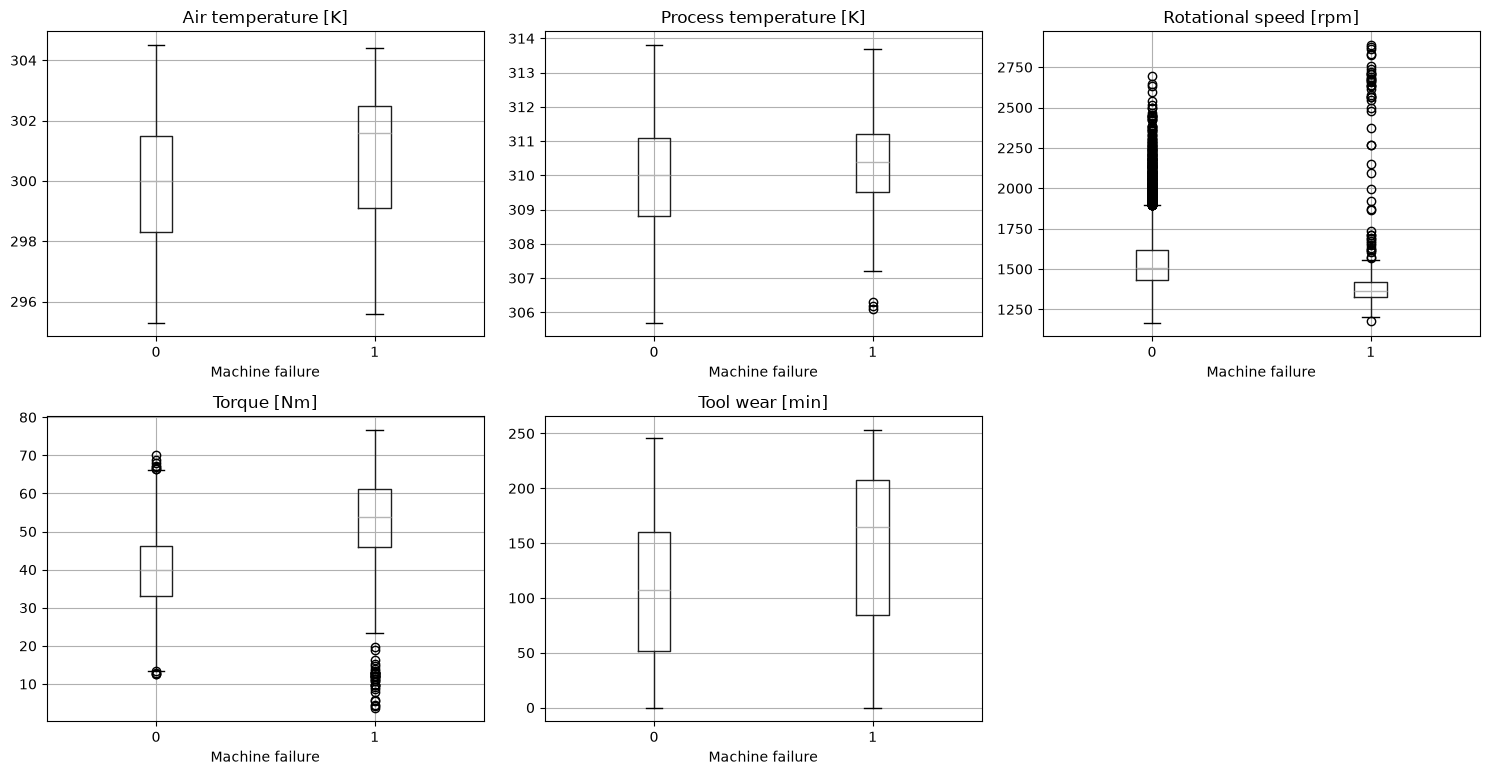

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by="Machine failure", ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("Machine failure")

axes[-1].axis("off")
plt.suptitle("")  # quita el título automático feo que pone pandas
plt.tight_layout()
plt.show()

**Análisis:**
- **Torque**: la separación es clara — las máquinas que fallan tienen una mediana
  de torque notablemente más alta (~54 Nm) que las que no fallan (~40 Nm), aunque
  también hay algunos casos de falla con torque muy bajo. Tiene sentido: esto
  coincide con el mecanismo de falla **PWF** (potencia fuera de rango, ya sea muy
  alta o muy baja) y **OSF** (desgaste × torque excede un límite).
- **Tool wear**: las máquinas que fallan también tienen mediana más alta (~160 min
  vs. ~105 min) y mayor dispersión — coincide con el mecanismo **TWF** (desgaste
  entre 200-240 min).
- **Rotational speed**: el patrón es inverso — las fallas tienden a tener velocidad
  **más baja** (mediana ~1350 rpm vs. ~1500 rpm), consistente con el mecanismo
  **HDF** (que requiere velocidad baja). Ambos grupos muestran outliers hacia
  velocidades altas.
- **Air temperature** y **Process temperature**: la diferencia entre grupos es
  mucho más sutil — las máquinas que fallan tienden a una mediana ligeramente más
  alta, pero se solapan bastante. Son las variables menos discriminantes por sí
  solas.

En conjunto, Torque, Tool wear y Rotational speed se ven como las variables más
prometedoras para que el modelo distinga entre fallas y no fallas — algo que
podemos confirmar más adelante con la importancia de variables del modelo.

## 6. Variable categórica `Type` vs. tasa de falla

`Type` indica la calidad del producto (L = Low, M = Medium, H = High). Vale la pena
revisar si la calidad del producto influye en la probabilidad de falla.

In [28]:
print(df["Type"].value_counts())
print()

failure_rate_by_type = df.groupby("Type")["Machine failure"].mean().reindex(["L", "M", "H"]) * 100
print("Tasa de falla (%) por Type:")
print(failure_rate_by_type.round(2))

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Tasa de falla (%) por Type:
Type
L    3.92
M    2.77
H    2.09
Name: Machine failure, dtype: float64


**Análisis:** hay un patrón claro y monótono: a menor calidad del producto, mayor
tasa de falla — L (baja calidad) falla 3.92% de las veces, M (media) 2.77%, y H
(alta) solo 2.09%. Esto tiene sentido de negocio (piezas de menor calidad
aguantan menos) y coincide con el diseño del dataset: el mecanismo de falla OSF
(Overstrain Failure) usa un límite de desgaste×torque distinto según la variante
del producto, más exigente para L que para H. Aunque la diferencia no es enorme,
`Type` sí aporta información útil y vale la pena incluirla como variable
categórica en el modelo (habrá que codificarla, por ejemplo con one-hot encoding).

## 7. Correlación entre variables numéricas

Por último en el EDA de variables, miramos cómo se correlacionan entre sí las
variables numéricas (incluyendo la variable objetivo). Esto ayuda a detectar
relaciones fuertes entre predictoras (que podrían ser redundantes) y cuáles se
relacionan más con `Machine failure`.

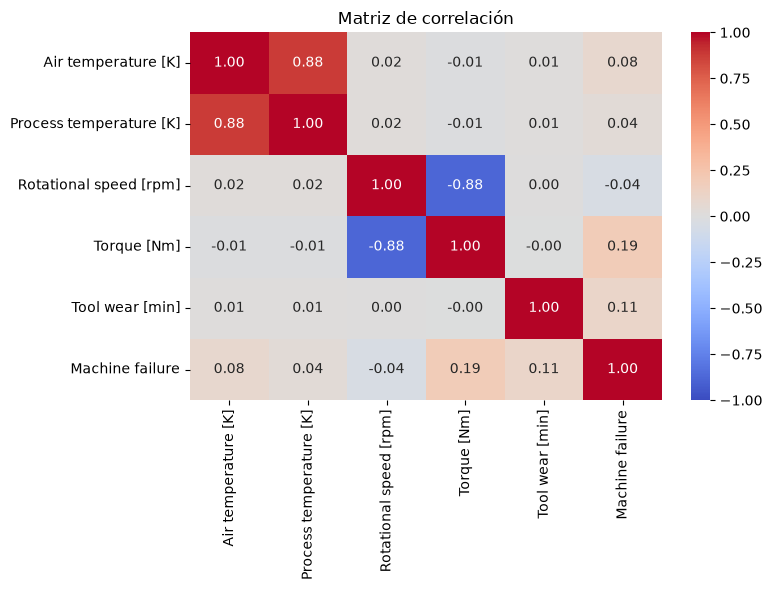

In [29]:


corr_cols = num_cols + ["Machine failure"]
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

**Análisis:**
- **Air temperature y Process temperature: 0.88** (correlación fuerte) — esperado,
  porque por diseño `Process temperature = Air temperature + 10K + ruido`. Son
  parcialmente redundantes entre sí.
- **Rotational speed y Torque: -0.88** (correlación negativa fuerte) — también
  esperado, por la relación física de que la potencia se mantiene aproximadamente
  constante (a mayor velocidad, menor torque necesario, y viceversa).
- **Correlación de cada variable con `Machine failure`: todas son débiles**
  (máximo 0.19 con Torque, 0.11 con Tool wear, 0.08 con Air temperature). Esto
  puede parecer contradictorio con lo que vimos en los boxplots del Paso 5, donde
  Torque y Tool wear sí separaban bien las clases — pero no lo es: la correlación
  lineal (Pearson) solo detecta relaciones *lineales* simples, mientras que los
  mecanismos de falla del dataset son **condicionales/de interacción** (ej. OSF
  depende de `desgaste × torque` superando un umbral, no de cada variable por
  separado). Esto sugiere que un modelo capaz de capturar interacciones y
  relaciones no lineales (como Random Forest) probablemente va a funcionar mejor
  que uno puramente lineal (como Regresión Logística simple) — algo que vamos a
  poder comprobar comparando ambos modelos en el baseline.

## 8. Modos de falla específicos (TWF, HDF, PWF, OSF, RNF)

El dataset incluye 5 banderas que indican el mecanismo específico de cada falla.
No es el foco del MVP (que es clasificación binaria de `Machine failure`), pero
vale la pena entender qué tan frecuente es cada mecanismo, como insumo para la
extensión de alcance mencionada en la Sección 1.1.

In [30]:
failure_flags = ["TWF", "HDF", "PWF", "OSF", "RNF"]
flag_counts = df[failure_flags].sum().sort_values(ascending=False)
print("Conteo de activaciones por tipo de falla:")
print(flag_counts)

sin_bandera = df[(df["Machine failure"] == 1) & (df[failure_flags].sum(axis=1) == 0)]
print(f"\nFallas sin ninguna bandera de tipo activa: {len(sin_bandera)}")

Conteo de activaciones por tipo de falla:
HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64

Fallas sin ninguna bandera de tipo activa: 9


**Análisis:**
- El mecanismo más frecuente es **HDF** (115 casos), seguido de **OSF** (98),
  **PWF** (95), **TWF** (46) y por último **RNF** (19) — tiene sentido que RNF sea
  el menos común, ya que por diseño ocurre con solo 0.1% de probabilidad,
  independiente de las demás variables.
- La suma de las banderas (115+98+95+46+19 = **373**) es **mayor** que el total de
  fallas (339). Esto significa que **algunas fallas se disparan por más de un
  mecanismo a la vez** (por ejemplo, una misma falla puede cumplir tanto la
  condición de TWF como la de OSF simultáneamente).
- Hay **9 fallas sin ninguna bandera activa** — un detalle a documentar como
  particularidad del dataset sintético (posible ruido en cómo se generaron las
  banderas), sin que afecte el MVP porque el target principal es `Machine failure`,
  no las banderas individuales.

Esto confirma que el MVP (clasificación binaria de `Machine failure`) es la ruta
correcta para el alcance actual, y que clasificar los 5 tipos de falla (alcance
extra) sería más complejo de lo normal por esta superposición entre mecanismos —
técnicamente sería un problema de clasificación multi-etiqueta, no multi-clase.

## 9. Resumen de hallazgos del EDA

Antes de pasar a modelar, un resumen de lo que encontramos:

- **Calidad de los datos:** el dataset está completamente limpio — 0 nulos, 0
  duplicados en las 10.000 filas. No se requiere limpieza previa.
- **Desbalance de clases:** solo 3.39% de las observaciones son fallas (339/10.000).
  Esto confirma la decisión de la Sección 1.1 de usar Recall/Precision/F1/AUC-PR en
  vez de accuracy, y de estratificar el split train/test por la variable objetivo.
- **Variables más prometedoras:** Torque, Tool wear y Rotational speed muestran
  separación visible entre fallas y no-fallas en los boxplots (aunque su
  correlación lineal con el target es baja, porque los mecanismos de falla son
  condicionales/de interacción, no lineales). `Type` también aporta señal: a menor
  calidad del producto, mayor tasa de falla.
- **Redundancia entre predictoras:** Air temperature y Process temperature están
  muy correlacionadas entre sí (0.88), igual que Rotational speed y Torque (-0.88)
  — no es necesariamente un problema para modelos de árboles, pero es bueno
  tenerlo presente.
- **Los 5 tipos de falla se superponen entre sí** (la suma de banderas supera el
  total de fallas), lo que confirma que el MVP debe enfocarse en clasificación
  binaria de `Machine failure`, dejando la clasificación de tipos de falla
  (multi-etiqueta, más compleja) como alcance extra si alcanza el tiempo.

**Próximos pasos:** preparar los datos (split train/test estratificado, encoding de
`Type`, escalado) y entrenar un modelo baseline para comparar contra uno más
robusto.

## 10. Preparación de datos

Separamos las variables predictoras (`X`) de la variable objetivo (`y`), dejando
fuera del set de predictoras las 5 banderas de tipo de falla (`TWF`, `HDF`, `PWF`,
`OSF`, `RNF`) — porque en un escenario real, esas banderas normalmente no se
conocerían de antemano (son casi una consecuencia de la falla, no un predictor
disponible antes de que ocurra). Luego hacemos el split train/test, **estratificado**
por `Machine failure` para que la proporción de fallas (3.39%) se mantenga igual en
ambos conjuntos.

In [31]:

failure_flags = ["TWF", "HDF", "PWF", "OSF", "RNF"]
X = df.drop(columns=["Machine failure"] + failure_flags)
y = df["Machine failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "  Test:", X_test.shape)
print("Proporción de fallas en train:", round(y_train.mean(), 4))
print("Proporción de fallas en test: ", round(y_test.mean(), 4))

Train: (8000, 8)   Test: (2000, 8)
Proporción de fallas en train: 0.0339
Proporción de fallas en test:  0.034


**Análisis:** el split quedó correcto — 8.000 filas para entrenar y 2.000 para
probar (80/20), y la proporción de fallas se mantuvo casi igual en ambos conjuntos
(0.0339 en train vs. 0.034 en test), confirmando que la estratificación funcionó
como se esperaba. Con esto evitamos el riesgo de que, por azar, el set de prueba
quede con muy pocas (o ninguna) fallas, lo cual haría imposible evaluar bien el
modelo en la clase que más nos importa.

## 11. Pipeline de preprocesamiento

Antes de entrenar, hay que transformar los datos: las variables numéricas se
escalan (StandardScaler, para que ninguna domine solo por tener valores más
grandes, como Rotational speed vs. Torque), y la variable categórica `Type` se
convierte a variables numéricas con one-hot encoding. Usamos un `ColumnTransformer`
de scikit-learn para aplicar cada transformación a las columnas que le corresponden,
de forma reproducible y sin fugas de información entre train y test.

In [32]:


numeric_features = num_cols  # las 5 variables numéricas que ya veníamos usando
categorical_features = ["Type"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
])

print(preprocessor)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Air temperature [K]',
                                  'Process temperature [K]',
                                  'Rotational speed [rpm]', 'Torque [Nm]',
                                  'Tool wear [min]']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['Type'])])


**Análisis:** el `ColumnTransformer` quedó configurado correctamente — escala las
5 variables numéricas con `StandardScaler` y convierte `Type` a variables dummy
con `OneHotEncoder` (usando `drop="first"` para evitar redundancia entre las 3
categorías L/M/H). Este preprocesador se va a usar dentro de un `Pipeline` junto
con cada modelo, para que las transformaciones se ajusten (`fit`) solo con los
datos de entrenamiento y no haya fuga de información hacia el set de prueba.

## 12. Comparación de 10 modelos, con manejo consistente del desbalance

Entrenamos 10 algoritmos de clasificación, todos con el mismo preprocesamiento
(`preprocessor`). Como se discutió: **no** castigamos ambos tipos de error por
igual a propósito — un falso negativo (no detectar una falla real) es más costoso
para el negocio que un falso positivo (falsa alarma), como se definió en la
Sección 1.1. Por eso todos los modelos reciben el mismo trato asimétrico durante
el entrenamiento, aplicado de la forma que cada algoritmo soporta:

- **`class_weight="balanced"`** (parámetro nativo): Regresión Logística, Árbol de
  Decisión, Random Forest, Extra Trees, SVM.
- **`sample_weight`** en el `.fit()` (para los que no tienen `class_weight`):
  Gradient Boosting, Hist Gradient Boosting, AdaBoost, Naive Bayes.
- **K-Nearest Neighbors** es el único que **no soporta ninguna de las dos formas**
  de ponderar el entrenamiento por clase — queda como limitación conocida del
  algoritmo, no un descuido nuestro.

Registramos qué método de ponderación usó cada modelo en la propia tabla de
resultados, para que quede documentado y sea fácil de auditar.

In [33]:

modelos = {
    "Regresion Logistica": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Arbol de Decision": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "SVM": SVC(class_weight="balanced", probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
}

# Modelos que ya reciben el trato asimetrico via su propio parametro class_weight
modelos_con_class_weight = {
    "Regresion Logistica", "Arbol de Decision", "Random Forest", "Extra Trees", "SVM"
}
# Modelos sin class_weight, pero que si aceptan sample_weight en el .fit()
modelos_con_sample_weight = {
    "Gradient Boosting", "Hist Gradient Boosting", "AdaBoost", "Naive Bayes"
}
# K-Nearest Neighbors no soporta ninguna de las dos -> queda sin ponderar (limitacion conocida)

sample_weight_train = compute_sample_weight(class_weight="balanced", y=y_train)

resultados = []
for nombre, modelo in modelos.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", modelo),
    ])

    if nombre in modelos_con_sample_weight:
        pipeline.fit(X_train, y_train, classifier__sample_weight=sample_weight_train)
        manejo = "sample_weight"
    elif nombre in modelos_con_class_weight:
        pipeline.fit(X_train, y_train)
        manejo = "class_weight"
    else:
        pipeline.fit(X_train, y_train)
        manejo = "sin ponderar (no soportado)"

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    resultados.append({
        "modelo": nombre,
        "recall_falla": recall_score(y_test, y_pred),
        "precision_falla": precision_score(y_test, y_pred, zero_division=0),
        "f1_falla": f1_score(y_test, y_pred),
        "auc_pr": average_precision_score(y_test, y_proba),
        "manejo_desbalance": manejo,
    })

resultados_df = pd.DataFrame(resultados).sort_values("recall_falla", ascending=False).reset_index(drop=True)
resultados_df.round(4)

c:\Users\diana\OneDrive\Escritorio\Carolina_Tobon\proyecto\aprendizaje-automatico-en-la-nube\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,modelo,recall_falla,precision_falla,f1_falla,auc_pr,manejo_desbalance
0,SVM,0.8971,0.2723,0.4178,0.6161,class_weight
1,Gradient Boosting,0.8676,0.3224,0.4701,0.6623,sample_weight
2,AdaBoost,0.8529,0.2624,0.4014,0.4907,sample_weight
3,Regresion Logistica,0.8235,0.1418,0.2419,0.3817,class_weight
4,Naive Bayes,0.7941,0.1517,0.2547,0.2629,sample_weight
5,Hist Gradient Boosting,0.7941,0.7297,0.7606,0.8343,sample_weight
6,Random Forest,0.6912,0.7344,0.7121,0.7814,class_weight
7,Arbol de Decision,0.6176,0.7000,0.6562,0.4454,class_weight
8,K-Nearest Neighbors,0.2794,0.8261,0.4176,0.4653,sin ponderar (no soportado)
9,Extra Trees,0.2794,1.0000,0.4368,0.7152,class_weight


**Análisis:**

Aplicar el mismo trato asimétrico a los modelos de boosting tuvo efectos muy
distintos según el algoritmo:

- **Hist Gradient Boosting** mejoró de forma "sana": Recall subió de 0.7353 a
  **0.7941** (prácticamente tocando la meta de 0.80), mientras que Precision
  (0.7297) y AUC-PR (0.8343, el mejor de los 10 modelos) se mantuvieron altos.
  Sigue siendo, por mucho, el modelo con mejor balance general.
- **Gradient Boosting** y **AdaBoost**, en cambio, "sobre-corrigieron": su Recall
  subió mucho (0.8676 y 0.8529) pero su Precision se desplomó (0.32 y 0.26) y su
  AUC-PR también bajó bastante frente a la versión sin ponderar. Esto sugiere que
  estos algoritmos no combinan bien con un `sample_weight` externo — AdaBoost, por
  ejemplo, ya tiene su propio mecanismo interno de reponderar ejemplos difíciles
  en cada iteración, y sumarle otro peso externo lo desestabiliza en vez de
  ayudarlo.
- **SVM** sigue siendo el de mayor Recall (0.8971) pero la Precision más baja
  después de Regresión Logística — confirma que no es una opción práctica.

**Conclusión / modelo elegido:** **Hist Gradient Boosting** es el modelo ganador —
mejor F1 (0.7606) y mejor AUC-PR (0.8343) de los 10, con Recall (0.7941) casi
exactamente en la meta declarada en la Sección 1.1, y Precision razonable (0.73).
Queda como el "modelo más robusto" del MVP, comparado contra Regresión Logística
como baseline. Este hallazgo también deja una lección de buenas prácticas: aplicar
la misma técnica de balanceo a todos los modelos por igual **no garantiza el mismo
beneficio** — hay que evaluar el efecto en cada algoritmo, no asumirlo. Para la
Fase 2 queda pendiente ajustar el umbral de decisión de Hist Gradient Boosting
(su AUC-PR alto sugiere que hay margen para subir el Recall a 0.80+ sin sacrificar
mucha Precision).

## 13. Matriz de confusión del modelo ganador (Hist Gradient Boosting)

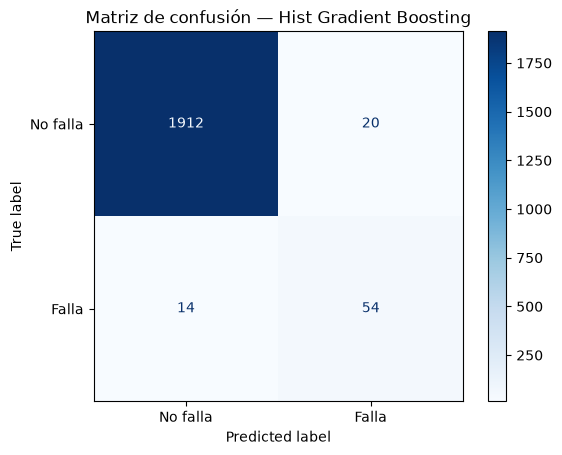

In [34]:

mejor_modelo = "Hist Gradient Boosting"
pipeline_ganador = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(random_state=42)),
])
pipeline_ganador.fit(X_train, y_train, classifier__sample_weight=sample_weight_train)
y_pred_ganador = pipeline_ganador.predict(X_test)

cm = confusion_matrix(y_test, y_pred_ganador)
ConfusionMatrixDisplay(cm, display_labels=["No falla", "Falla"]).plot(cmap="Blues")
plt.title(f"Matriz de confusión — {mejor_modelo}")
plt.show()

## 14. Conclusiones generales

- El dataset AI4I 2020 está limpio (sin nulos/duplicados) y fuertemente
  desbalanceado (3.39% de fallas), lo que exigió elegir bien las métricas
  (Recall/Precision/F1/AUC-PR) desde la Sección 1.1.
- Torque, Tool wear y Rotational speed son las variables más predictivas de
  `Machine failure`; `Type` (calidad del producto) también aporta señal.
- Se compararon 10 algoritmos con el mismo preprocesamiento y el mismo trato
  asimétrico del error (más peso a no dejar pasar una falla real), documentando
  qué mecanismo de ponderación usó cada uno.
- **Modelo baseline:** Regresión Logística. **Modelo más robusto elegido:**
  Hist Gradient Boosting (mejor F1 y AUC-PR, Recall 0.7941 muy cerca de la meta
  de 0.80, Precision razonable de 0.73).
- Con esto queda satisfecho el MVP de la Fase 1.3 (Sección 1.1): EDA completo +
  modelo baseline y uno más robusto, comparados.

**Pendiente para la Fase 2 (Experiment Tracking):**
- Ajustar el umbral de decisión de Hist Gradient Boosting para intentar cruzar el
  Recall ≥ 0.80 sin perder tanta Precision.
- Tracking formal de experimentos con MLflow.
- Probar SMOTE (imbalanced-learn) como alternativa/complemento al sample_weight.
- Tuning de hiperparámetros con Optuna.
- Validación cruzada, en vez de un solo split train/test.